# FraudDetectAI — Credit Card Fraud Detection

Comparing machine learning approaches on a real-world, highly imbalanced dataset 
of European credit card transactions (September 2013, ULB). All features V1–V28 
are PCA-transformed for confidentiality. Data is loaded from PostgreSQL.

## Dataset at a glance
| | |
|---|---|
| Total transactions | 284,807 |
| Fraudulent cases | 492 (0.172%) |
| Features | 30 (V1–V28, Time, Amount, Class) |
| Transaction window | 2 days |

## Approaches compared
- **SMOTE** — synthetic oversampling of the minority class before classification
- **Class weight balancing** — penalises minority misclassification during training
- **Isolation Forest** — anomaly detection, no label balancing required

## Evaluation strategy
Accuracy is misleading on imbalanced data — a model predicting *no fraud* every 
time scores 99.8%. We use AUPRC, ROC-AUC, F1, and SHAP for explainability.

---
*Data source: [ULB Machine Learning Group — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)*

In [60]:
import os
import warnings
from pathlib import Path

import joblib

# Visualisation
import matplotlib.pyplot as plt

# Data
import numpy as np

# Hyperparameter tuning
import optuna
import pandas as pd
import seaborn as sns

# Explainability
import shap

# TensorFlow
import tensorflow as tf

# DB 
from dotenv import load_dotenv

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from optuna.samplers import TPESampler

# Models
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# Data splitting and preprocessing
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sqlalchemy import create_engine, text
from tensorflow import keras
from tensorflow.keras import layers
from xgboost import XGBClassifier

# Settings
SEED = 42
TEST_SIZE = 0.2

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

## Database Connection

In [17]:
load_dotenv()

DB_URL = (
    f"postgresql://"
    f"{os.getenv('POSTGRES_USER', 'postgres')}:"
    f"{os.getenv('POSTGRES_PASSWORD', 'postgres')}@"
    f"localhost:5432/"
    f"{os.getenv('POSTGRES_DB', 'frauddetect')}"
)

engine = create_engine(DB_URL)

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM transactions;"))
    count = result.scalar()
    
print(f"Total transactions in the database: {count}")

Total transactions in the database: 284807


**Get Column Names**:

In [18]:
with engine.connect() as conn:
    res = conn.execute(text("SELECT * FROM transactions WHERE 1=0;"))

print("Columns in the dataset:")
print(res.keys())

Columns in the dataset:
RMKeyView(['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class'])


**Class Distribution**

In [19]:
# ── Class distribution ────────────────────────────────────────────────────────
query = """
    SELECT 
        class,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 4) AS percentage
    FROM transactions
    GROUP BY class
    ORDER BY class;
"""

with engine.connect() as conn:
    class_dist = pd.read_sql(text(query), conn)

print("Class distribution:\n")
print(class_dist.to_string(index=False))

Class distribution:

 class  count  percentage
     0 284315     99.8273
     1    492      0.1727


## EDA

In [20]:
# Load the dataset into a DataFrame
query = "SELECT * FROM transactions;"
with engine.connect() as conn:
    df = pd.read_sql(text(query), conn)

print(df.shape)

(284807, 31)


In [21]:
df.head()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [22]:
# Missing values per feature & duplicates
missing_values = df.isnull().sum()[df.isnull().sum() > 0]

print("Missing values per feature:\n")
print(missing_values.to_string())

print(f"\nDuplicated rows: {df.duplicated().sum()}")

Missing values per feature:

Series([], )



Duplicated rows: 1081


In [23]:
# Duplicates per class
dupes = df[df.duplicated(keep=False)]
print(f"Duplicated rows per class:\n{dupes['class'].value_counts()}")

Duplicated rows per class:
class
0    1822
1      32
Name: count, dtype: int64


In [24]:
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)
print(df["class"].value_counts())

(283726, 31)
class
0    283253
1       473
Name: count, dtype: int64


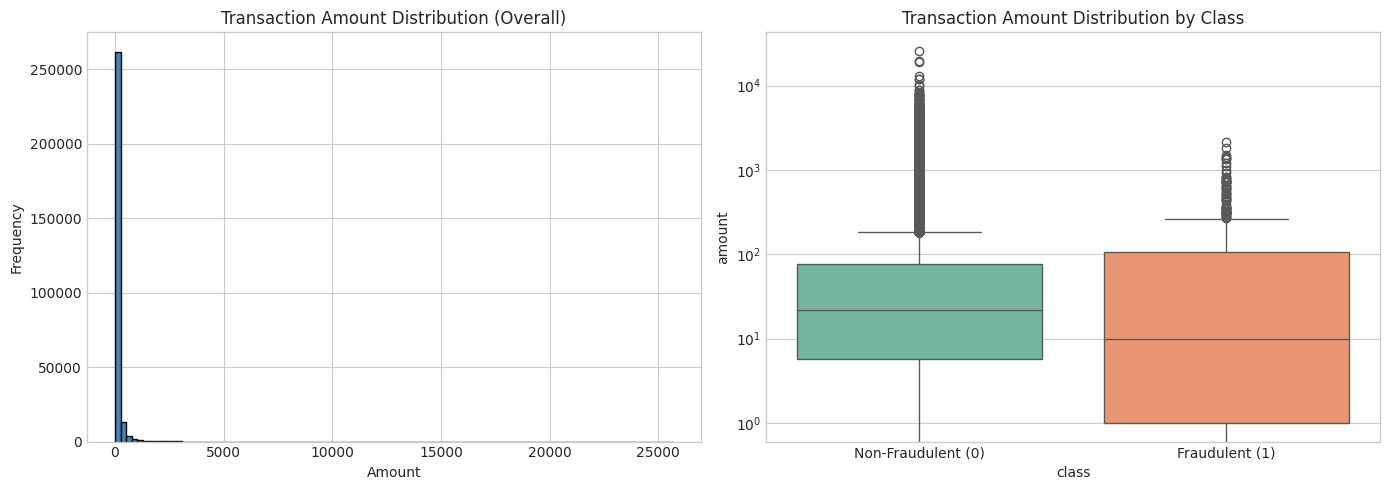

In [25]:
# Amount distribution overall and by class
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax[0].hist(df["amount"], bins=100, color="steelblue", edgecolor="black")
ax[0].set_title("Transaction Amount Distribution (Overall)")
ax[0].set_xlabel("Amount")
ax[0].set_ylabel("Frequency")

# By class distribution
sns.boxplot(data=df, x="class", y="amount", ax=ax[1], palette="Set2")
ax[1].set_title("Transaction Amount Distribution by Class")
ax[1].set_yscale("log")
ax[1].set_xticklabels(["Non-Fraudulent (0)", "Fraudulent (1)"])

plt.tight_layout()
plt.show()

In [26]:
print(df.groupby("class")["amount"].describe())

            count     mean      std    min    25%     50%      75%        max
class                                                                        
0     283253.0000  88.4136 250.3790 0.0000 5.6700 22.0000  77.4600 25691.1600
1        473.0000 123.8719 260.2110 0.0000 1.0000  9.8200 105.8900  2125.8700


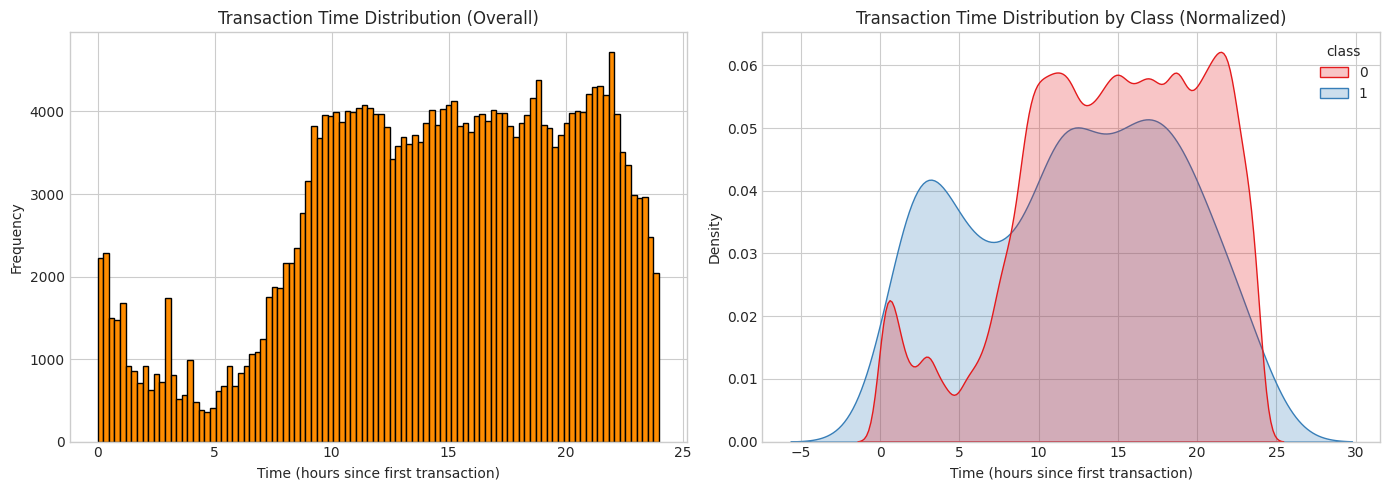

In [27]:
# Convert time to hours since first transaction
df["hour_of_day"] = (df["time"] % 86400) / 3600

# Time Distribution overall and by class
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Time Distribution overall
ax[0].hist(df["hour_of_day"], bins=100, color="darkorange", edgecolor="black")
ax[0].set_title("Transaction Time Distribution (Overall)")
ax[0].set_xlabel("Time (hours since first transaction)")
ax[0].set_ylabel("Frequency")

# Time Distribution by class
sns.kdeplot(data=df, x="hour_of_day", hue="class", ax=ax[1], fill=True, palette="Set1", common_norm=False)
ax[1].set_title("Transaction Time Distribution by Class (Normalized)")
ax[1].set_xlabel("Time (hours since first transaction)")
ax[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [28]:
# Correlation for v1-28
corr_with_class = df.drop(columns=["time", "amount", "hour_of_day"]).corr()["class"].drop("class")
corr_with_class = corr_with_class.reindex(corr_with_class.abs().sort_values(ascending=False).index)

print(corr_with_class)

v17   -0.3135
v14   -0.2934
v12   -0.2507
v10   -0.2070
v16   -0.1872
v3    -0.1823
v7    -0.1723
v11    0.1491
v4     0.1293
v18   -0.1053
v1    -0.0945
v9    -0.0940
v5    -0.0878
v2     0.0846
v6    -0.0439
v19    0.0336
v8     0.0331
v21    0.0264
v27    0.0219
v20    0.0215
v28    0.0097
v24   -0.0072
v23   -0.0063
v22    0.0049
v26    0.0043
v13   -0.0039
v15   -0.0033
v25    0.0032
Name: class, dtype: float64


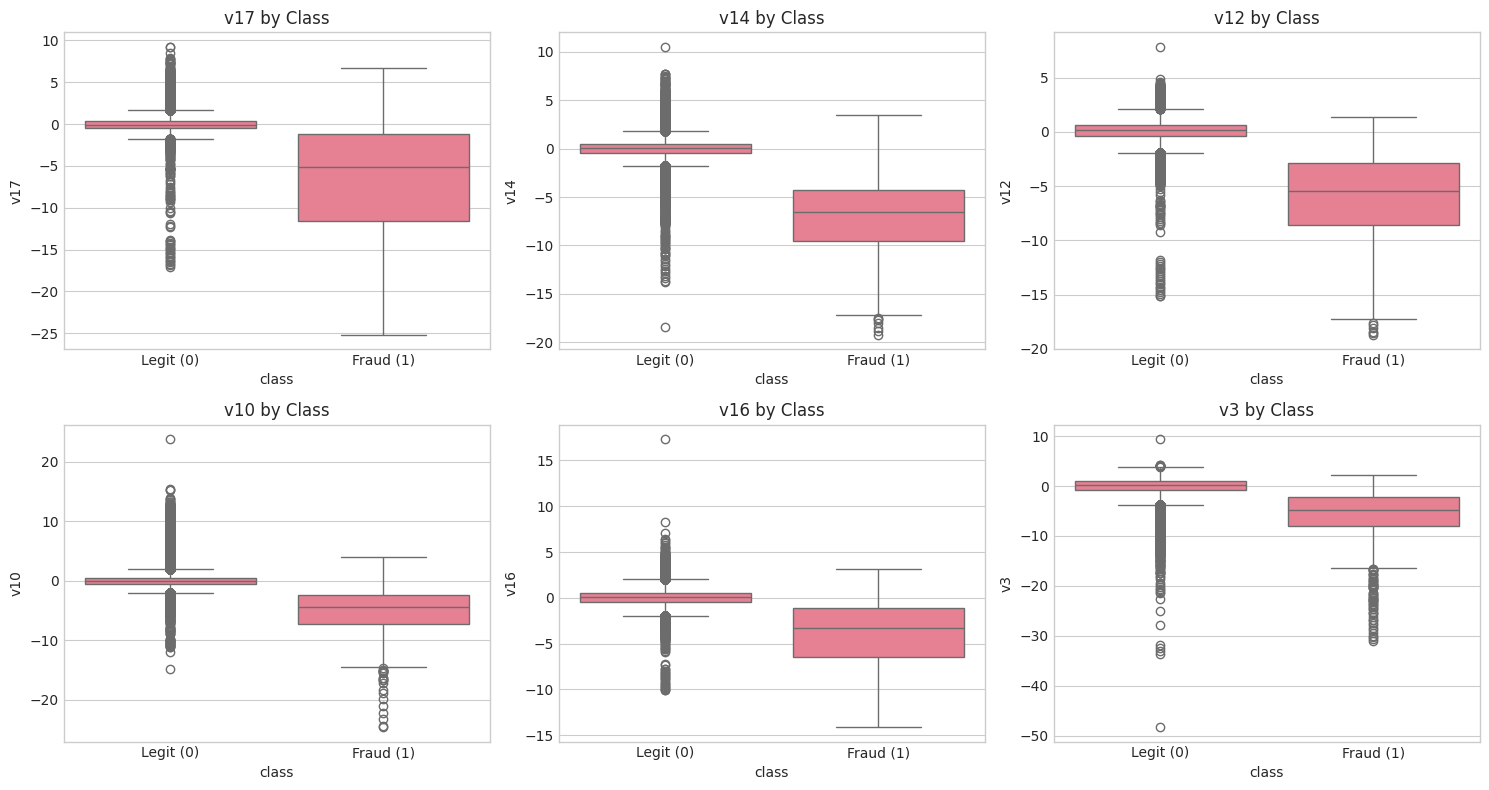

In [29]:
# Visualize top correlated features with class
top_features = corr_with_class.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.boxplot(data=df, x="class", y=feat, ax=axes[i])
    axes[i].set_title(f"{feat} by Class")
    axes[i].set_xticklabels(["Legit (0)", "Fraud (1)"])

plt.tight_layout()
plt.show()

## Model Training

In [30]:
# X and y
X = df.drop(columns=["class"])
y  = df["class"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print(f"Train shape: {X_train.shape}, Fraud in train: {y_train.sum()}")
print(f"Test shape: {X_test.shape}, Fraud in test: {y_test.sum()}")

Train shape: (226980, 31), Fraud in train: 378
Test shape: (56746, 31), Fraud in test: 95


**Scaling with RobustScaler**

In [31]:
# Scale features
scale_columns = ["amount", "hour_of_day"]

scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test_scaled[scale_columns] = scaler.transform(X_test[scale_columns])

X_train_scaled[scale_columns].describe()

,amount,hour_of_day
count,226980.0000,226980.0000
mean,0.9189,-0.0535
std,3.4059,0.6688
min,-0.3060,-1.7195
25%,-0.2271,-0.5048
50%,0.0000,0.0000
75%,0.7729,0.4952
max,272.0960,1.0293


**StratifiedKFold Setup**

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Logistic Regression

#### Class Weight

In [33]:
# Base Pipeline
base_pipeline = Pipeline([
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=SEED
    ))
])

# Cross-validation scores for the base pipeline
scores = cross_val_score(
    base_pipeline, X_train_scaled, y_train, cv=cv, scoring="average_precision", n_jobs=-1
)

print("Baseline Logistic Regression (class_weight='balanced')")
print(f"Average Precision (PR-AUC): {scores.mean():.4f} ± {scores.std():.4f}")

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

Baseline Logistic Regression (class_weight='balanced')
Average Precision (PR-AUC): 0.7520 ± 0.0261


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### SMOTE

In [34]:
# SMOTE Pipeline
smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])

# Cross-validation scores for the SMOTE pipeline
scores_smote = cross_val_score(
    smote_pipeline, X_train_scaled, y_train, cv=cv, scoring="average_precision", n_jobs=-1
)

print("SMOTE + Logistic Regression")
print(f"Average Precision (PR-AUC): {scores_smote.mean():.4f} ± {scores_smote.std():.4f}")

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

SMOTE + Logistic Regression
Average Precision (PR-AUC): 0.7563 ± 0.0261


/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### XGBoost

#### Class Weight

In [35]:
# Scale pos weight for XGBoost
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Pipeline for XGBoost
xgb_weighted_pipeline = Pipeline([
    ("clf", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1
    ))
])

# Cross-validation scores for the XGBoost pipeline
scores_xgb = cross_val_score(
    xgb_weighted_pipeline, X_train_scaled, y_train, cv=cv, scoring="average_precision", n_jobs=-1
)

print("Class-weighted XGBoost (scale_pos_weight)")
print(f"Average Precision (PR-AUC): {scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")


scale_pos_weight: 599.48


Class-weighted XGBoost (scale_pos_weight)
Average Precision (PR-AUC): 0.8489 ± 0.0278


#### SMOTE

In [36]:
# SMOTE Pipeline for XGBoost
smote_xgb_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("clf", XGBClassifier(
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1
    ))
])

# Cross-validation scores for the SMOTE + XGBoost pipeline
scores_smote_xgb = cross_val_score(
    smote_xgb_pipeline, X_train_scaled, y_train, cv=cv, scoring="average_precision", n_jobs=-1
)

print("SMOTE + XGBoost")
print(f"Average Precision (PR-AUC): {scores_smote_xgb.mean():.4f} ± {scores_smote_xgb.std():.4f}")

SMOTE + XGBoost
Average Precision (PR-AUC): 0.8575 ± 0.0313


#### Metric Comparison Table

In [37]:
# Set up scoring metrics for cross-validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "pr_auc": "average_precision",
}

# Set up models for evaluation
models = {
    "LogReg (class_weight)": base_pipeline,
    "LogReg + SMOTE": smote_pipeline,
    "XGB (class_weight)": xgb_weighted_pipeline,
    "XGB + SMOTE": smote_xgb_pipeline,
}

results = []

for name, pipe in models.items():
    cv_results = cross_validate(pipe, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "Model": name,
        "Accuracy": np.mean(cv_results["test_accuracy"].mean()),
        "Precision": np.mean(cv_results["test_precision"].mean()),
        "Recall": np.mean(cv_results["test_recall"].mean()),
        "PR-AUC": np.mean(cv_results["test_pr_auc"].mean()),
    })

results_df = pd.DataFrame(results).set_index("Model").sort_values(by="PR-AUC", ascending=False)
results_df.round(4)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

,Accuracy,Precision,Recall,PR-AUC
Model,,,,
XGB + SMOTE,0.9995,0.8404,0.8359,0.8575
XGB (class_weight),0.9996,0.9058,0.8280,0.8489
LogReg + SMOTE,0.9902,0.1408,0.8889,0.7563
LogReg (class_weight),0.9743,0.0566,0.9126,0.7520


#### Optuna for XGBoost (Class_Weight)

In [38]:
# Optuna objective function for hyperparameter tuning of XGBoost
def objective(trial):
    # Optimize hyperparameters
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", scale_pos_weight * 0.5, scale_pos_weight * 1.5),
        "random_state": SEED,
        "eval_metric": "aucpr",
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)

    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    return scores.mean()

In [39]:
# Run Optuna study for hyperparameter tuning
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, n_jobs=-1)

print(f"Best PR-AUC: {study.best_value:.4f}")
print(f"Best params:\n{study.best_params}")

Best PR-AUC: 0.8526
Best params:
{'n_estimators': 486, 'max_depth': 6, 'learning_rate': 0.05922412092300295, 'subsample': 0.7060674280827791, 'colsample_bytree': 0.7332557215535322, 'min_child_weight': 4, 'gamma': 3.55300837758538, 'reg_alpha': 0.21700157156265049, 'reg_lambda': 0.3778373582053448, 'scale_pos_weight': 490.7791998007592}


**Train and Evaluate the model**

In [40]:
# Train final model with best hyperparameters
best_params = study.best_params
best_params.update({
    "random_state": SEED,
    "eval_metric": "aucpr"
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7332557215535322, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='aucpr', feature_types=None, gamma=3.55300837758538,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05922412092300295,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=486, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [41]:
# Evaluate final model on the test set
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4, target_names=["Legit", "Fraud"]))

print(f"\nPR-AUC (Average Precision): {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Classification Report:

              precision    recall  f1-score   support

       Legit     0.9997    0.9999    0.9998     56651
       Fraud     0.9157    0.8000    0.8539        95

    accuracy                         0.9995     56746
   macro avg     0.9577    0.8999    0.9269     56746
weighted avg     0.9995    0.9995    0.9995     56746


PR-AUC (Average Precision): 0.8143
ROC-AUC: 0.9799


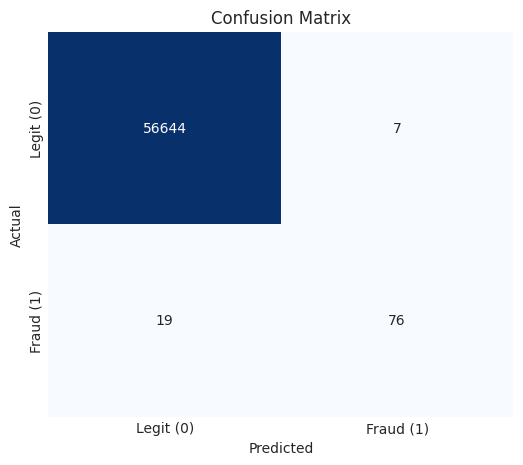

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Legit (0)", "Fraud (1)"], yticklabels=["Legit (0)", "Fraud (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### IsolationForest

In [43]:
# Isolation Forest for anomaly detection
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=y_train.mean(),
    random_state=SEED,
    n_jobs=-1
)

# Get Legit transactions from the training set for fitting
X_train_legit = X_train_scaled[y_train == 0]

iso_forest.fit(X_train_legit)

# Predict anomalies on the test set
y_pred_iso = iso_forest.predict(X_test_scaled)

# Convert predictions to binary labels (1 for fraud, 0 for legit)
y_pred_iso_binary = np.where(y_pred_iso == -1, 1, 0)

print("Isolation Forest Classification Report:\n")
print(classification_report(y_test, y_pred_iso_binary, digits=4, target_names=["Legit", "Fraud"]))

Isolation Forest Classification Report:

              precision    recall  f1-score   support

       Legit     0.9987    0.9984    0.9986     56651
       Fraud     0.2124    0.2526    0.2308        95

    accuracy                         0.9972     56746
   macro avg     0.6056    0.6255    0.6147     56746
weighted avg     0.9974    0.9972    0.9973     56746



**Evaluate**

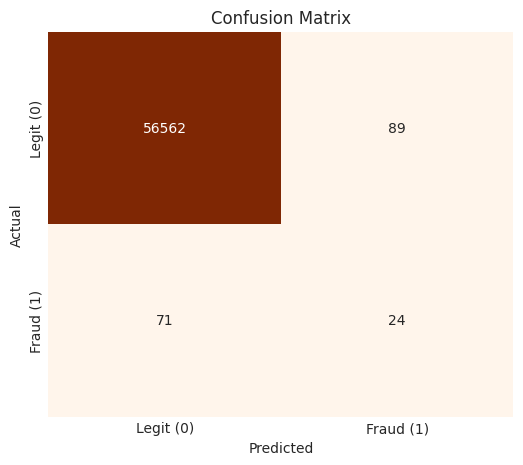

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_iso_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False, xticklabels=["Legit (0)", "Fraud (1)"], yticklabels=["Legit (0)", "Fraud (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()  

### AutoEncoder

In [45]:
# Input Dimension for Neural Network
input_dim = X_train_legit.shape[1]

# AutoEncoder
autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(20, activation="relu"),
    layers.Dense(14, activation="relu"),
    layers.Dense(7, activation="relu"),
    layers.Dense(14, activation="relu"),
    layers.Dense(20, activation="relu"),     
    layers.Dense(input_dim, activation="linear")       
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

E0000 00:00:1785073571.350842    7941 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           294 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 31)             │           651 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,102 (8.21 KB)

 Trainable params: 2,102 (8.21 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Train AutoEncoder
history = autoencoder.fit(
    X_train_legit,
    X_train_legit,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 4043042.0000 - val_loss: 2.3105
Epoch 2/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 650.0616 - val_loss: 1.8809
Epoch 3/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 500.1528 - val_loss: 110.0924
Epoch 4/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 617.2511 - val_loss: 57.8913
Epoch 5/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 641.7466 - val_loss: 1.8892
Epoch 6/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 567.1186 - val_loss: 1.7036
Epoch 7/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 490.2739 - val_loss: 2.0882
Epoch 8/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 537.3000 - val_loss: 1.7724
Epoch 9/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 487.4403 - val_loss: 2.0066
Epoch 10/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 545.6400 - val_loss: 1.9054
Epoch 11/50
6374/6374 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 424.1391 - val_los

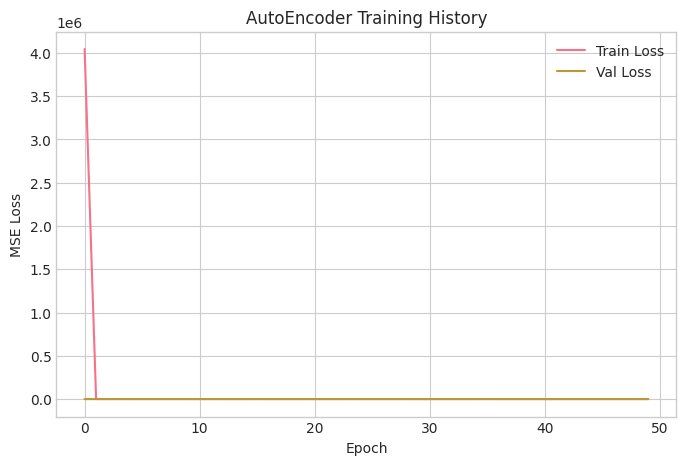

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("AutoEncoder Training History")
plt.legend()
plt.show()

In [48]:
# Reconstruct all test transactions (both legit and fraud)
X_test_reconstructed = autoencoder.predict(X_test_scaled)

# Per-sample reconstruction error (mean squared error across features)
reconstruction_errors = np.mean(np.square(X_test_scaled.values - X_test_reconstructed), axis=1)

# Sanity check: fraud should have higher average reconstruction error than legit
error_df = pd.DataFrame({"error": reconstruction_errors, "class": y_test.values})
print(error_df.groupby("class")["error"].describe())

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
           count    mean     std    min    25%     50%     75%       max
class                                                                   
0     56651.0000  2.2380 24.3168 0.1603 0.7711  1.4512  2.2067 5422.9560
1        95.0000 21.3359 28.1129 0.5136 4.7084 11.0968 20.9349  149.8059


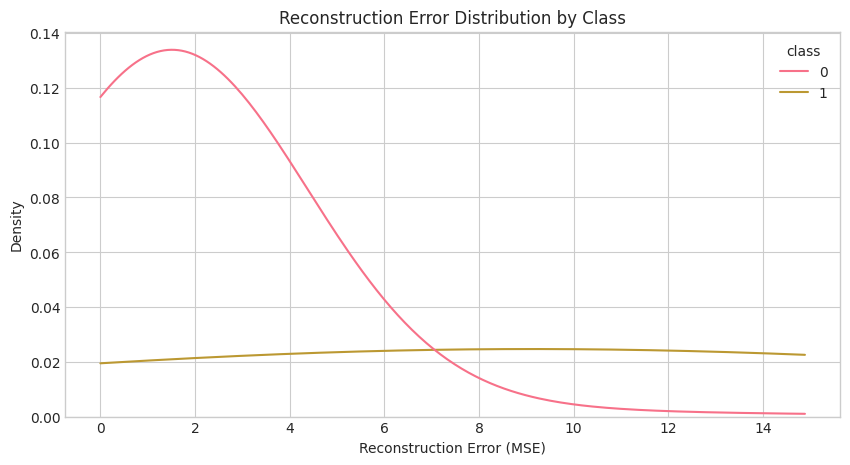

In [49]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=error_df, x="error", hue="class", common_norm=False, clip=(0, error_df["error"].quantile(0.99)))
plt.title("Reconstruction Error Distribution by Class")
plt.xlabel("Reconstruction Error (MSE)")
plt.show()

In [50]:
threshold = np.quantile(reconstruction_errors, 1 - y_train.mean())
print(f"Threshold: {threshold:.4f}")

y_pred_ae = (reconstruction_errors > threshold).astype(int)

print("\nAutoEncoder — Classification Report:\n")
print(classification_report(y_test, y_pred_ae, target_names=["Legit", "Fraud"]))

Threshold: 57.5627

AutoEncoder — Classification Report:

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.17      0.17      0.17        95

    accuracy                           1.00     56746
   macro avg       0.58      0.58      0.58     56746
weighted avg       1.00      1.00      1.00     56746



## XAI (Explainable AI with SHAP)

In [51]:
# Create SHAP explainer for the final XGBoost model
explainer = shap.TreeExplainer(final_model)

# Compute on part of test set
shap_sample = X_test_scaled.sample(n=2000, random_state=SEED)
shap_values = explainer.shap_values(shap_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 31)


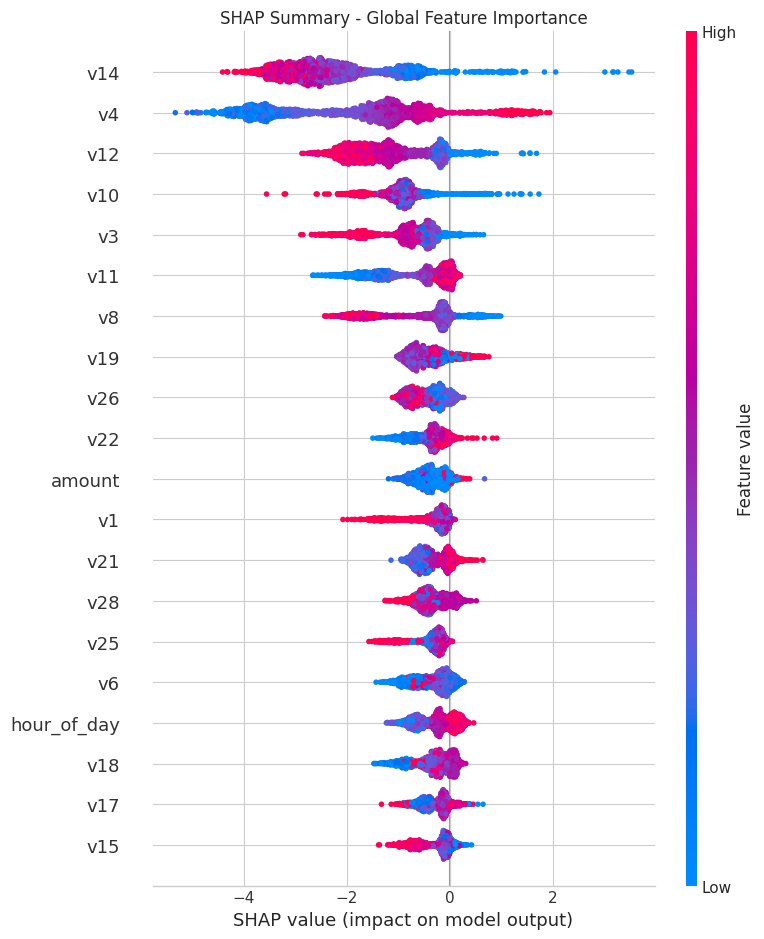

In [52]:
# Global Feature Importance (Summary Plot)
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Summary - Global Feature Importance")
plt.tight_layout()
plt.show()

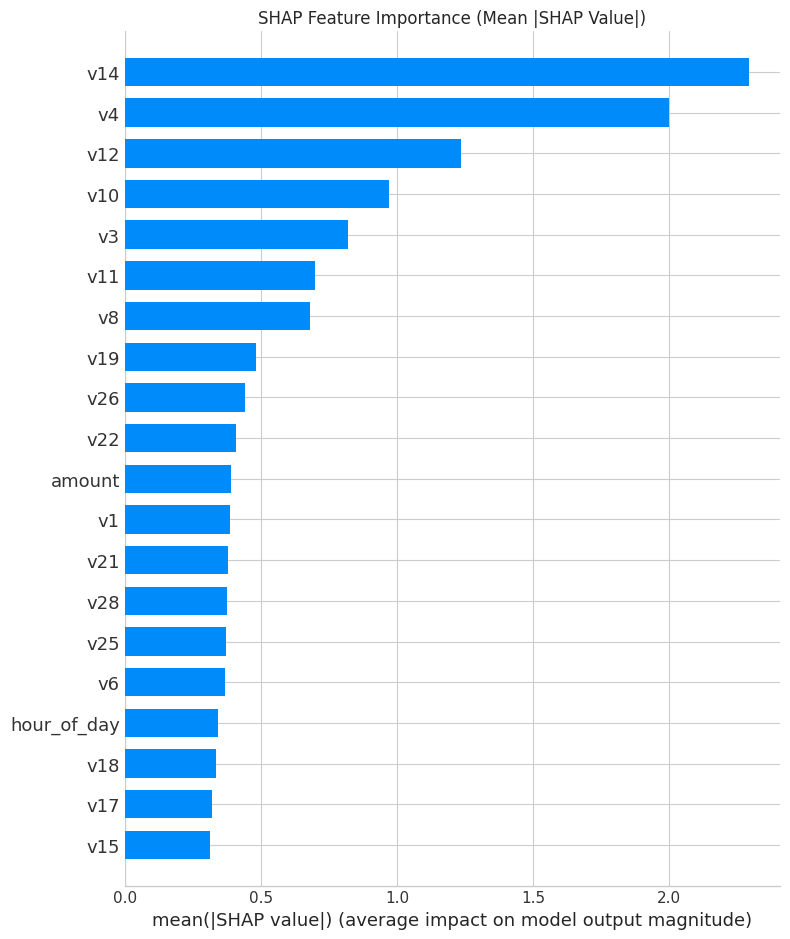

In [53]:
# Global Feature Importance (Bar Plot)
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)")
plt.tight_layout()
plt.show()

In [58]:
# Individual Prediction Explanation for a specific transaction (Fraud)
fraud_idx = y_test[y_test == 1].index[0]
single_row = X_test_scaled.loc[[fraud_idx]]
single_shap = explainer.shap_values(single_row)

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    single_shap[0],
    single_row.iloc[0]
)

## Save the Model and Scaler

In [61]:
# Path to save the final model
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Save the model
final_model.save_model(MODELS_DIR / "final_xgb_model.json")

# Save the scaler
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")

print(f"Final model and scaler saved to {MODELS_DIR.resolve()}")

Final model and scaler saved to /workspaces/models
